In [1]:
import sys
import importlib.util
import pickle
import pandas as pd
import geopandas as gpd
import numpy as np

from tqdm import tqdm
from sklearn.cluster import KMeans
from scipy.spatial.distance import euclidean

#plotting
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
#workaround for plotters import 

spec = importlib.util.spec_from_file_location("plotters", "/home/wuhlmann/BA/repo/lamah-ce_lstm/analysis/plotting/cell_state_plotters.py")
plotters = importlib.util.module_from_spec(spec)
sys.modules["plotters"] = plotters
spec.loader.exec_module(plotters)

from plotters import plot_cell_state_2d, plot_cell_state_3d

### Experimental cell state plots of single basins

May be interesting as a further investigation, if there is time. 

In [3]:
# full_q

full_q_states = []

with open("/home/wuhlmann/BA/data/processed_data/cell_states/full_q_512_3011_185525_cell_states_116.p", "rb") as f:
	full_q_states.append(pickle.load(f))

with open("/home/wuhlmann/BA/data/processed_data/cell_states/full_q_512_3011_185525_cell_states_117.p", "rb") as f:
	full_q_states.append(pickle.load(f))
	
with open("/home/wuhlmann/BA/data/processed_data/cell_states/full_q_512_3011_185525_cell_states_410.p", "rb") as f: 
	full_q_states.append(pickle.load(f))

with open("/home/wuhlmann/BA/data/processed_data/cell_states/full_q_512_3011_185525_cell_states_553.p", "rb") as f: 
	full_q_states.append(pickle.load(f))

# q_filter 

q_filter_states = []

with open("/home/wuhlmann/BA/data/processed_data/cell_states/512_batch_size_2711_095750_cell_states_116.p", "rb") as f:
	full_q_states.append(pickle.load(f))

with open("/home/wuhlmann/BA/data/processed_data/cell_states/512_batch_size_2711_095750_cell_states_117.p", "rb") as f:
	full_q_states.append(pickle.load(f))

with open("/home/wuhlmann/BA/data/processed_data/cell_states/512_batch_size_2711_095750_cell_states_410.p", "rb") as f: 
	 q_filter_states.append(pickle.load(f))

with open("/home/wuhlmann/BA/data/processed_data/cell_states/512_batch_size_2711_095750_cell_states_553.p", "rb") as f: 
	 q_filter_states.append(pickle.load(f))


In [4]:
mode = "normal"

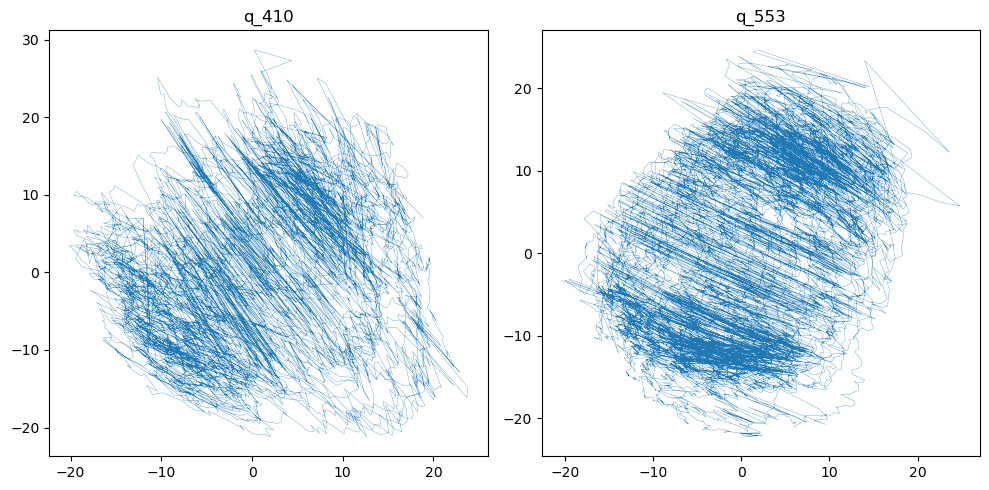

In [5]:
fig, axs = plt.subplots(1,2, figsize=(10,5))

for ax, array, title in zip(
	axs.ravel(),
	list(map(lambda x: x[mode], full_q_states[-2:])),
	["q_410", "q_553"]):
	
	# Assign every 365 points the same color, to look for seasonal patterns.
	point_colors = np.arange(len(array)) // 365

	plot_cell_state_2d(
		cell_state_array=array,
		ax=ax,
		title=title,
		connect=True, 
		linewidth=0.2
	)

plt.tight_layout()

### MDS of Average cell state plots of all basins

In [3]:
with open("/home/wuhlmann/BA/data/processed_data/cell_states/512_batch_size_2711_095750_cell_states_mds.p", "rb") as f: 
	filter_means_mds = pickle.load(f)
	
with open("/home/wuhlmann/BA/data/processed_data/cell_states/full_q_512_3011_185525_cell_states_mds.p", "rb") as f: 
	full_means_mds = pickle.load(f)


In [4]:
# load eval results
with open("/home/wuhlmann/BA/data/processed_data/evaluation/domain_metrics.p", "rb") as f: 
	domain_metrics = pickle.load(f)

In [5]:
strata_ids = pd.read_table("/home/wuhlmann/BA/data/processed_data/test_splits/strata_ids_incl_651.txt", header=0, sep=",")
strata_ids.set_index("ID", inplace=True)

In [6]:
lamah_gdf = gpd.read_file("/home/wuhlmann/BA/data/raw_data/2_LamaH-CE_daily/B_basins_intermediate_all/3_shapefiles/Basins_B.shp")
lamah_gdf.set_index("ID", inplace=True)
lamah_gdf["strata"] = strata_ids["0"]
lamah_gdf.sort_index(ascending=True, inplace=True)

In [7]:
#load in training ids, to distinguish between learned and unseen (val, test) cell states 
with open("/home/wuhlmann/BA/data/processed_data/test_splits/train_basin_ids.txt") as f: 
	train_ids_list = list(map(lambda x: int(x[:-1]),f.readlines())) 
	
for id in lamah_gdf.index: 
	
	if id in train_ids_list: 
		lamah_gdf.loc[id,"train_basin"] = True
	else: 
		lamah_gdf.loc[id, "train_basin"] = False

In [8]:
for period in domain_metrics.keys():
	
	for basin_id in domain_metrics[period].keys():
		lamah_gdf.loc[int(basin_id), "period"] = period
		lamah_gdf.loc[int(basin_id), "NSE"] = domain_metrics[period][basin_id]["1D"]["NSE"]
	

In [9]:
#lamah_gdf["NSE"] =(lamah_gdf["NSE"] - lamah_gdf["NSE"].mean()) / lamah_gdf["NSE"].std()
lamah_gdf["mds_x"] = full_means_mds["non-metric"]["raw"][:,0]
lamah_gdf["mds_y"] = full_means_mds["non-metric"]["raw"][:,1]

In [10]:
#represent


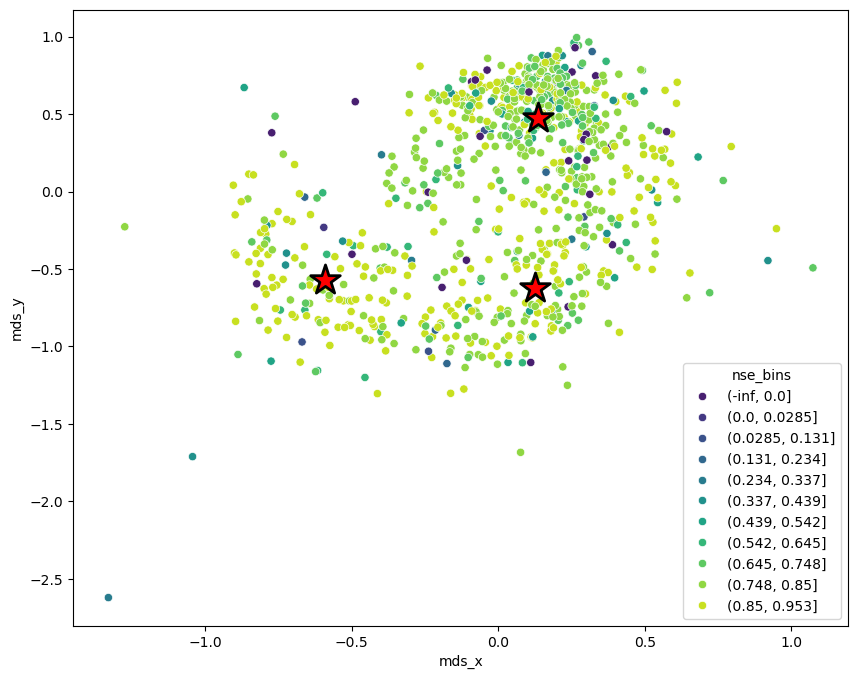

In [11]:
# Bin-Grenzen definieren
n_positive_bins = 9
pos_min = lamah_gdf.loc[lamah_gdf["NSE"] > 0, "NSE"].min()
pos_max = lamah_gdf["NSE"].max()

bins = np.concatenate((
	[-np.inf, 0],
	np.linspace(pos_min, pos_max, n_positive_bins + 1)
))

lamah_gdf["nse_bins"] = pd.cut(lamah_gdf["NSE"], bins=bins, include_lowest=True)

fig, ax = plt.subplots(figsize=(10, 8))
sns.scatterplot(
	data=lamah_gdf,
	x="mds_x",
	y="mds_y",
	hue="nse_bins",
	ax=ax,
	palette="viridis"
)

k_means = KMeans(3, random_state=1277, max_iter=100)

k_means.fit(full_means_mds["non-metric"]["raw"])
centers = k_means.cluster_centers_
ax.scatter(centers[:,0], centers[:,1], s=500, c='red', marker='*', edgecolors='black', linewidths=2, zorder=5)

<Axes: >

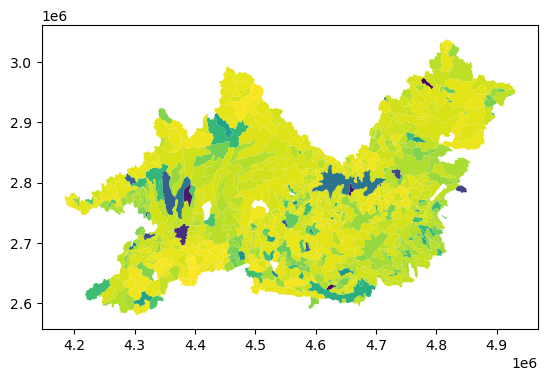

In [12]:
lamah_gdf[lamah_gdf.NSE > -1].plot(column="NSE")

0 basins could not be assined | (array([0, 1, 2], dtype=int32), array([244, 417, 198]))
0 basins could not be assined | (array([0, 1, 2], dtype=int32), array([231, 431, 197]))
0 basins could not be assined | (array([0, 1, 2], dtype=int32), array([221, 480, 158]))
0 basins could not be assined | (array([0, 1, 2], dtype=int32), array([318,   1, 540]))


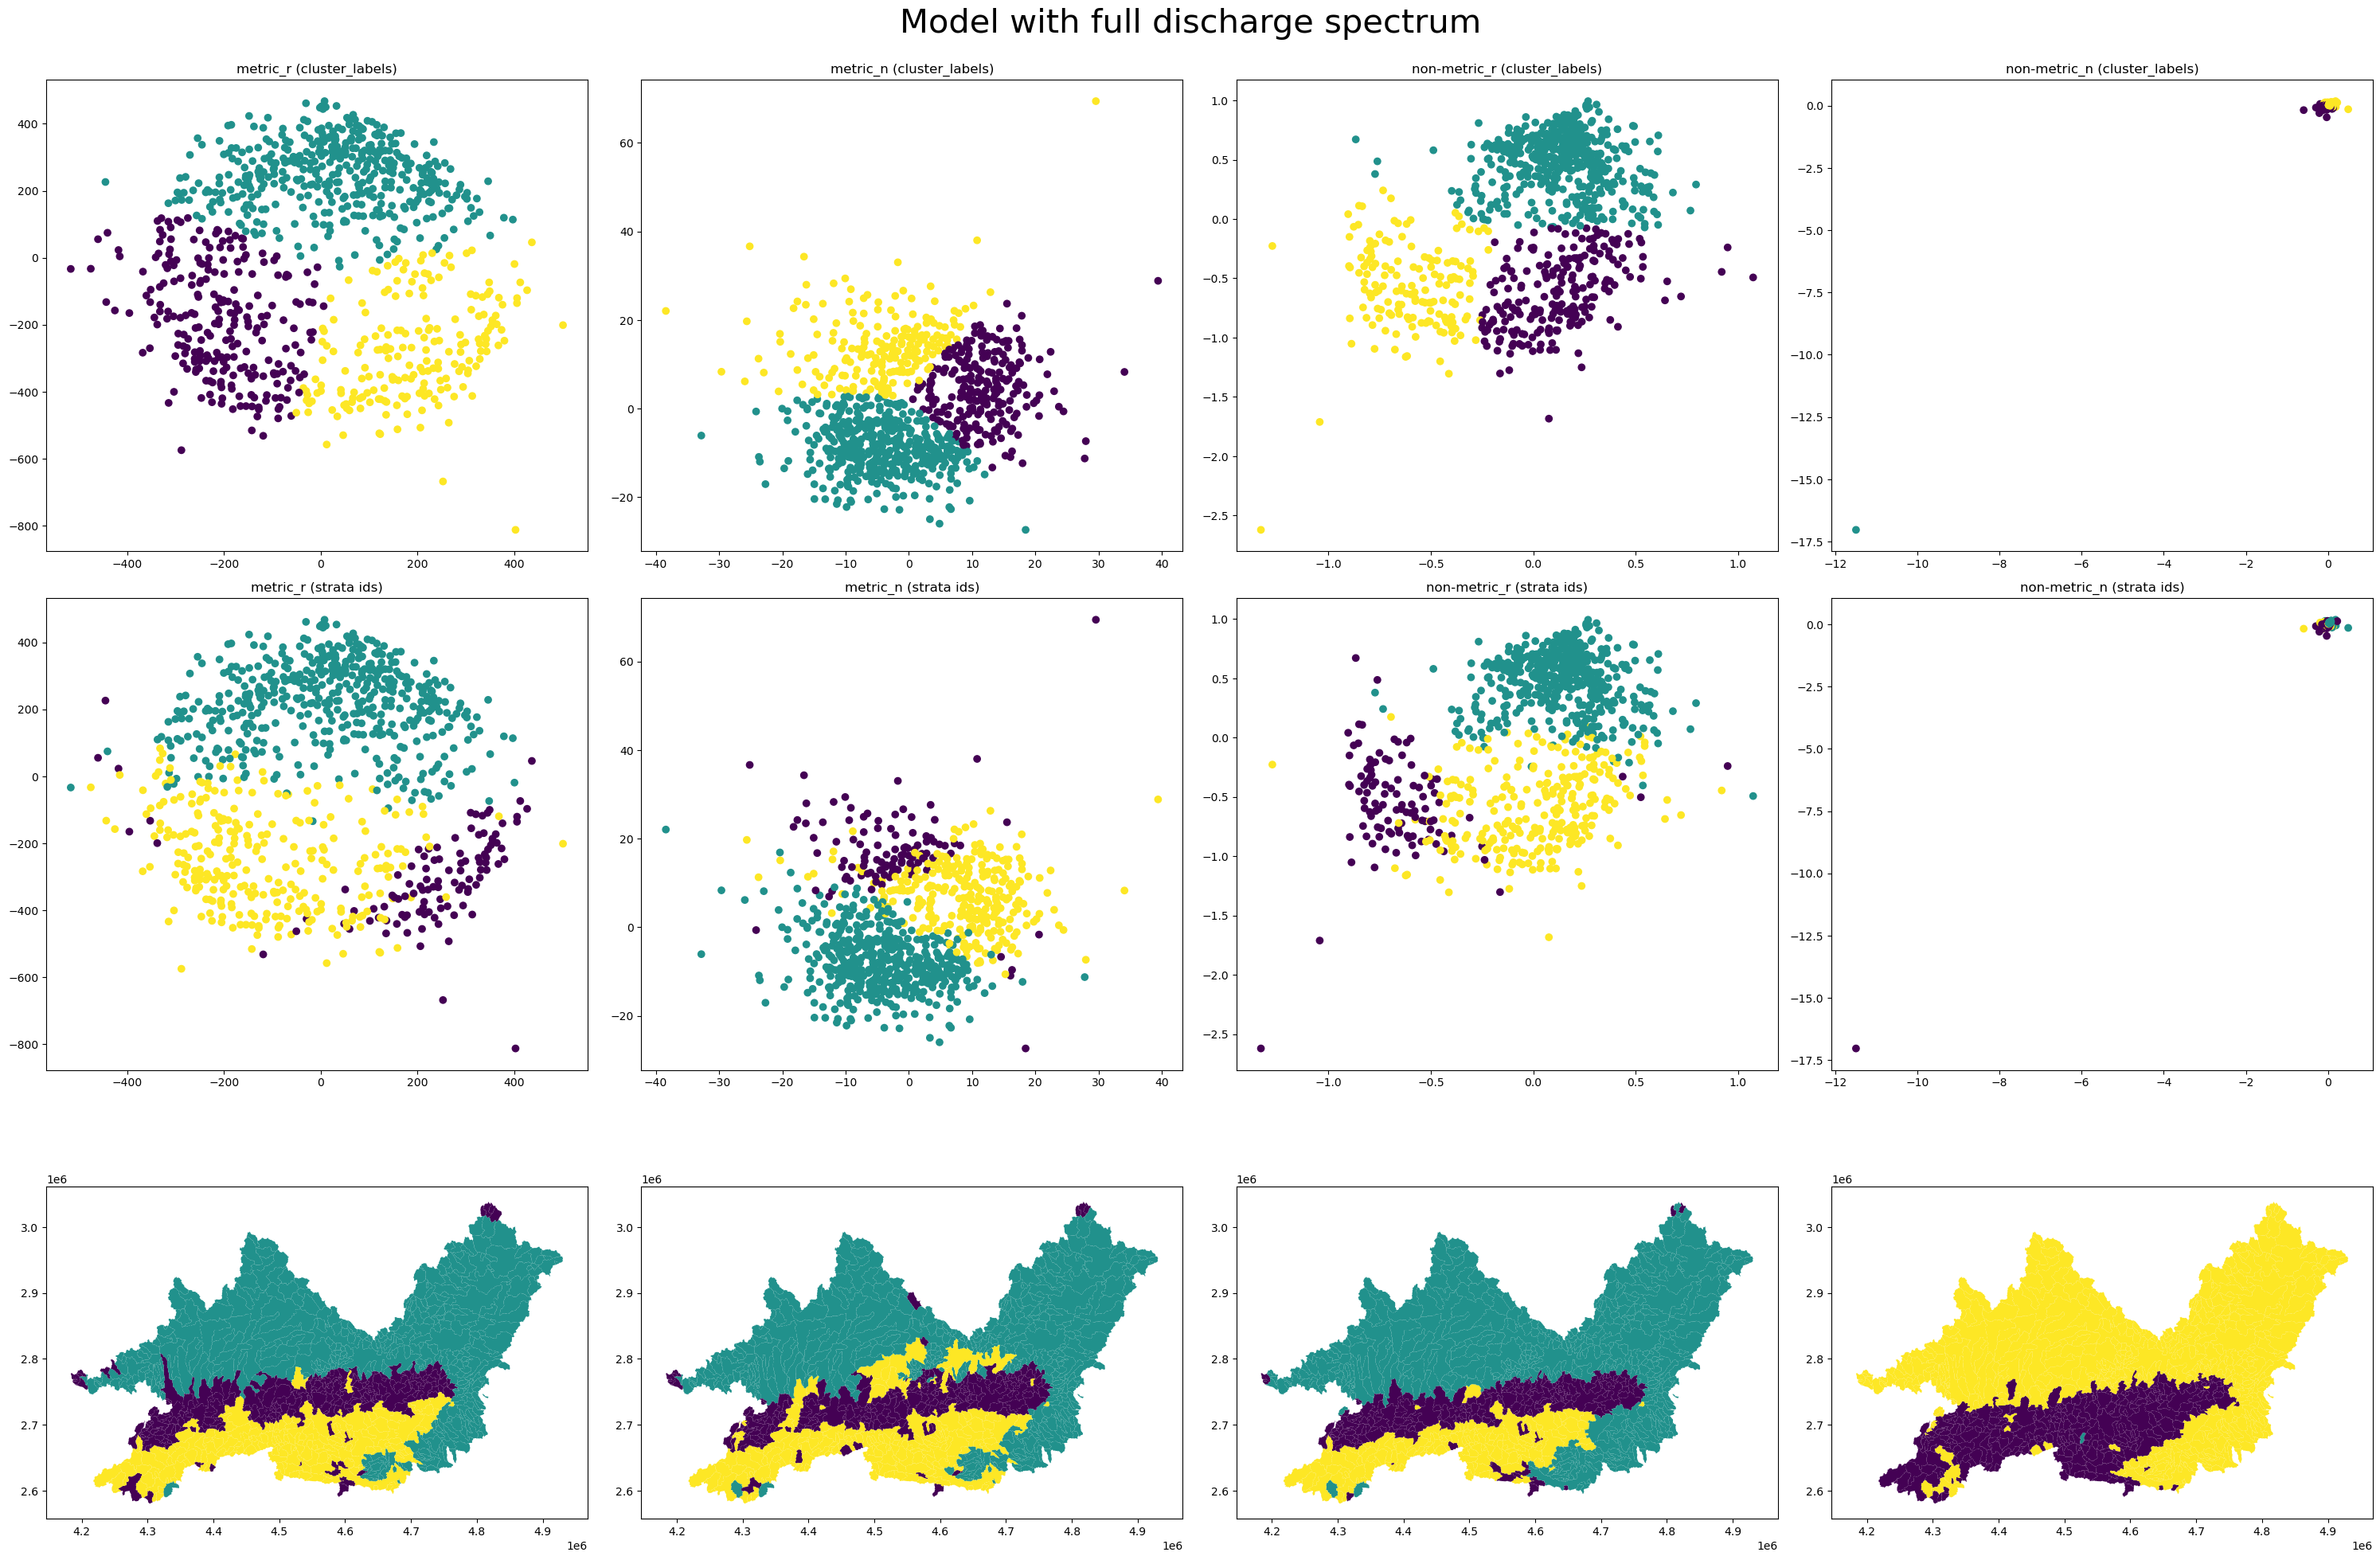

In [13]:
k_means = KMeans(3, random_state=1277, max_iter=100)

fig, axs = plt.subplots(3,4, figsize=(30,20))
axs = axs.ravel()
fig.suptitle("Model with full discharge spectrum", fontsize=30, y=1)

for i, array, title in zip(
	[0,1,2,3],
	[full_means_mds["metric"][m] for m in ["raw", "normal"]] + [full_means_mds["non-metric"][m] for m in ["raw", "normal"]],
	["metric_r", "metric_n", "non-metric_r", "non-metric_n"]
):
	
	cluster = k_means.fit_predict(array)

	print(f"{len(cluster[cluster==-1])} basins could not be assined | {np.unique(cluster, return_counts=True)}")

	lamah_gdf[f"cluster_full_{title}"] = cluster		
	plot_cell_state_2d(array[cluster!=-1], ax=axs[i], title=f"{title} (cluster_labels)", c=cluster[cluster !=-1])
	plot_cell_state_2d(array, ax=axs[i+4], title=f"{title} (strata ids)", c=strata_ids["0"])
	
	lamah_gdf.plot(ax=axs[i+8], column=f"cluster_full_{title}")

fig.savefig("/home/wuhlmann/BA/repo/lamah-ce_lstm/results/full_q_average_state_mds.png", dpi=300)
plt.tight_layout()

0 basins could not be assined | (array([0, 1, 2], dtype=int32), array([208, 185, 466]))


0 basins could not be assined | (array([0, 1, 2], dtype=int32), array([235, 429, 195]))
0 basins could not be assined | (array([0, 1, 2], dtype=int32), array([194, 477, 188]))
0 basins could not be assined | (array([0, 1, 2], dtype=int32), array([340,   1, 518]))


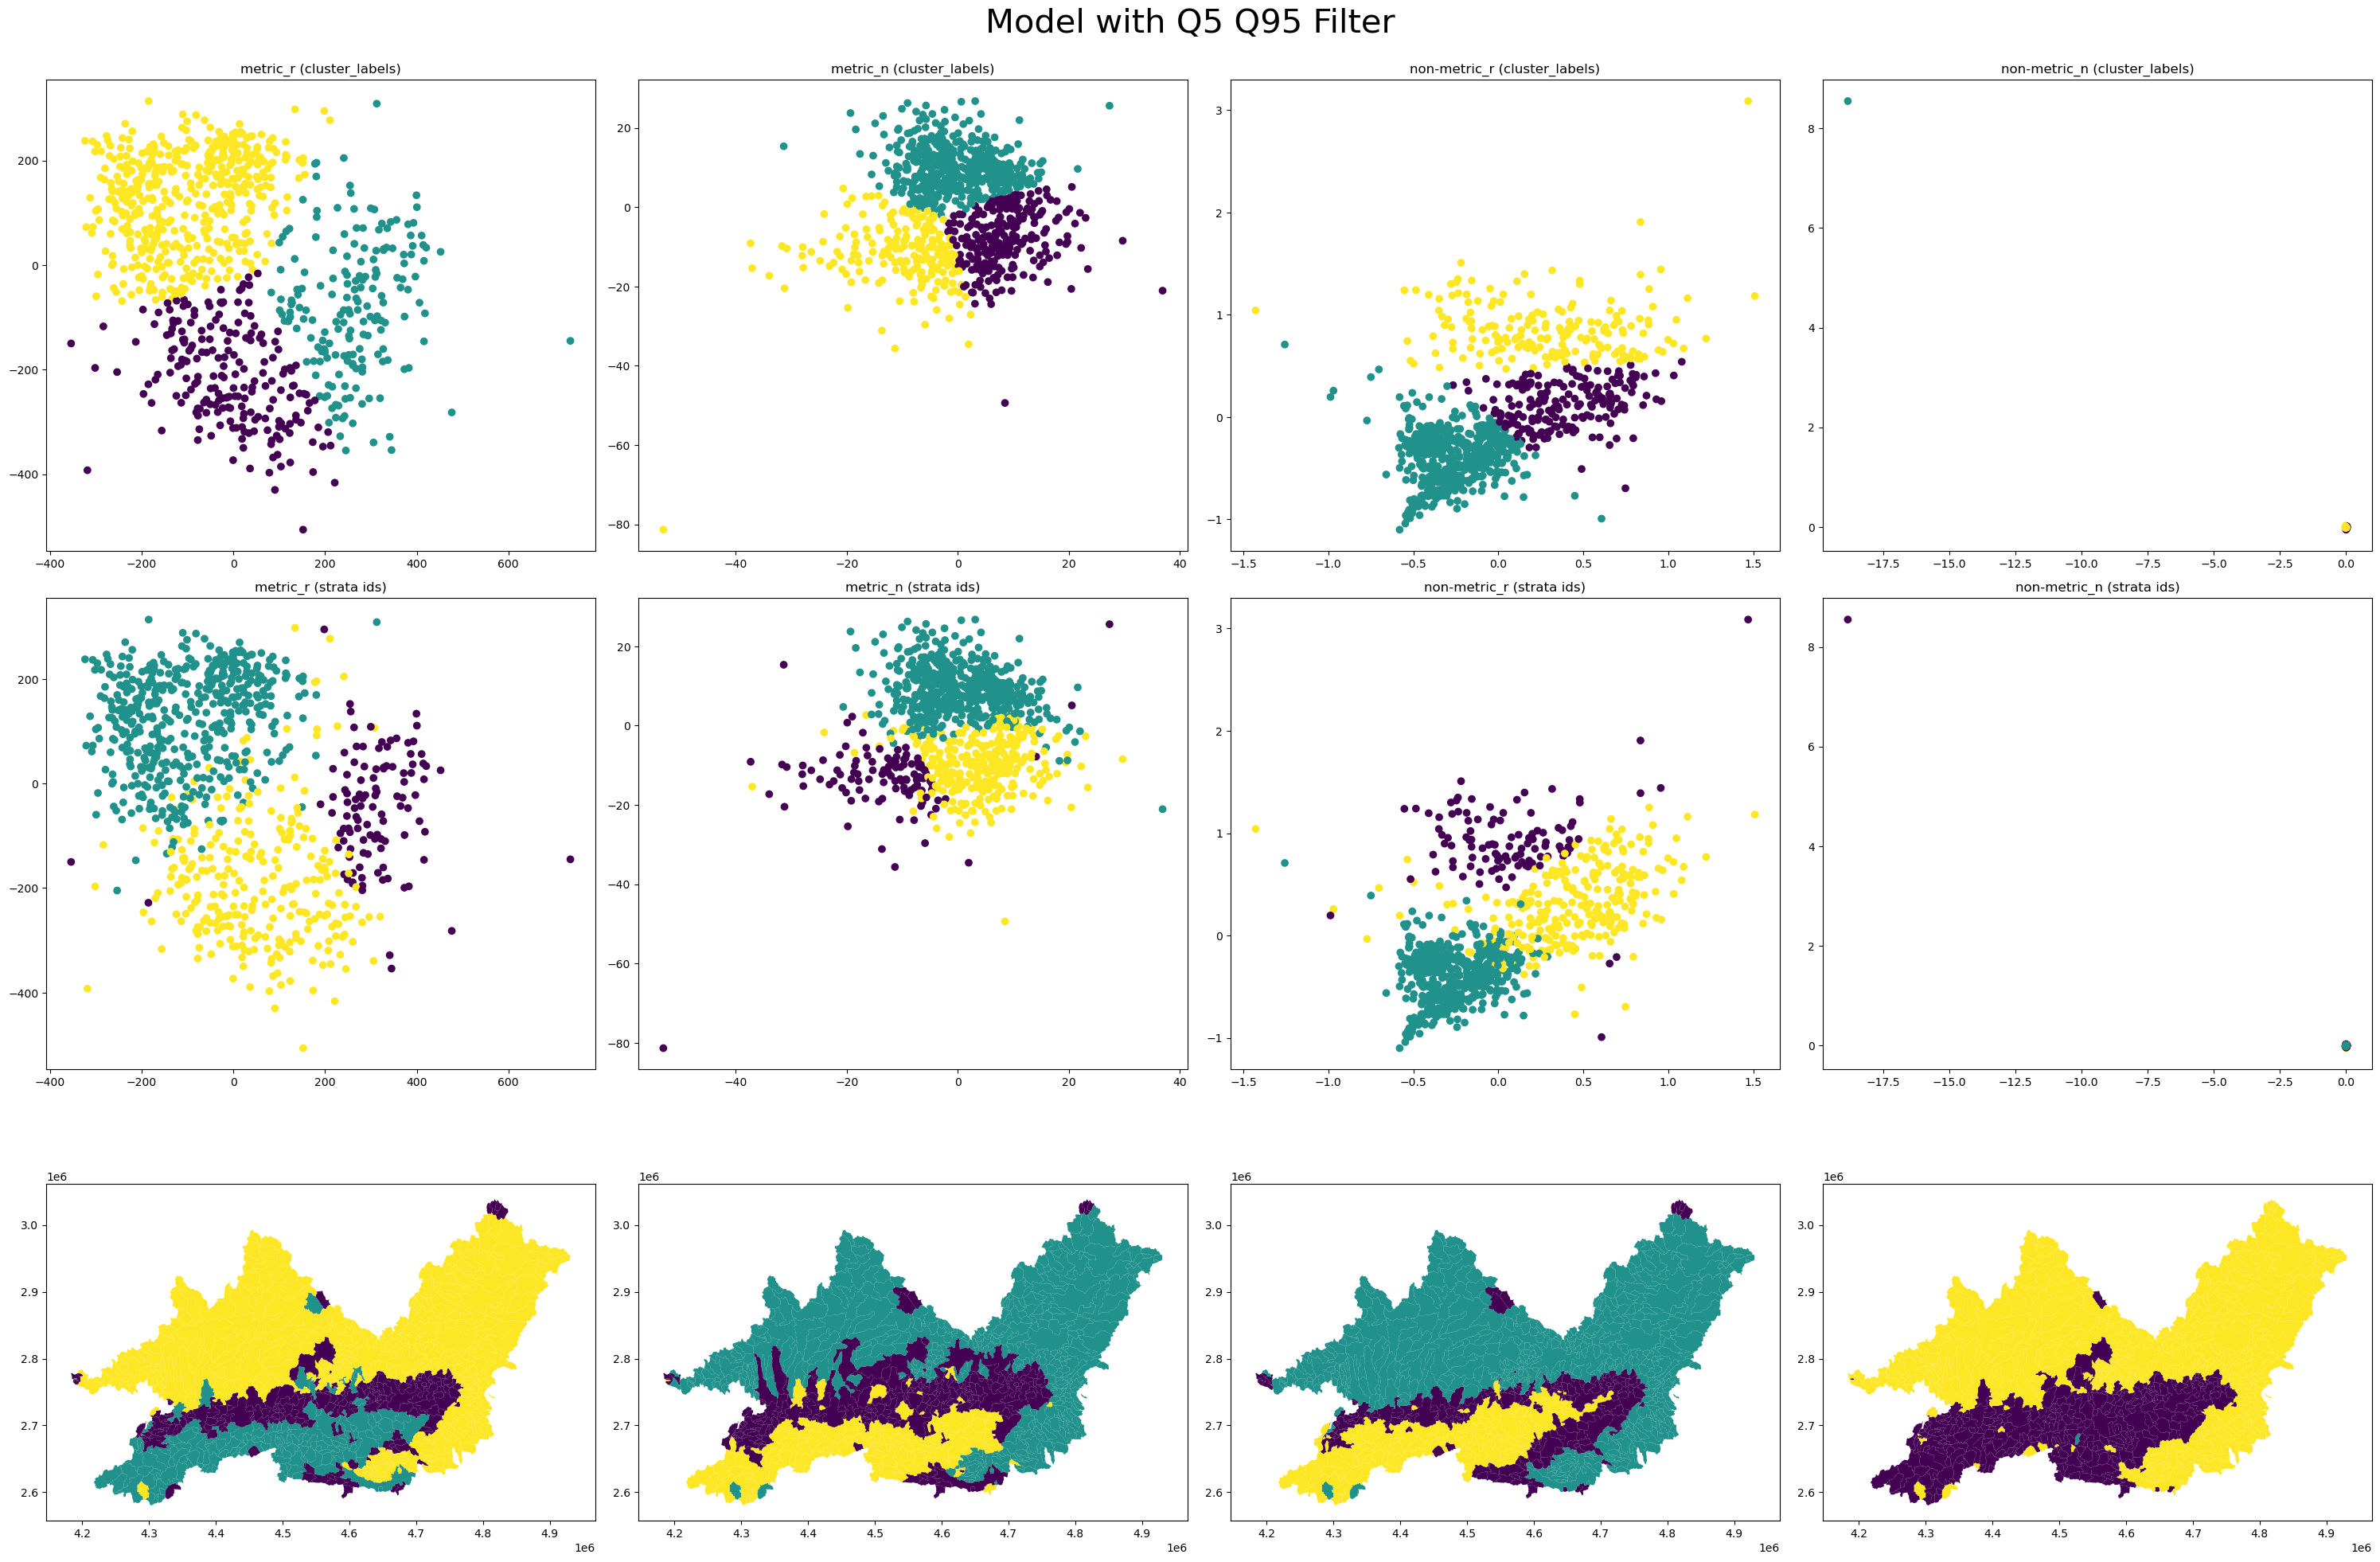

In [14]:
k_means = KMeans(3, random_state=1277, max_iter=100)

fig, axs = plt.subplots(3,4, figsize=(30,20))
axs = axs.ravel()
fig.suptitle("Model with Q5 Q95 Filter", fontsize=30, y=1)

for i, array, title in zip(
	[0,1,2,3],
	[filter_means_mds["metric"][m] for m in ["raw", "normal"]] + [filter_means_mds["non-metric"][m] for m in ["raw", "normal"]],
	["metric_r", "metric_n", "non-metric_r", "non-metric_n"]
):
	
	cluster = k_means.fit_predict(array)

	print(f"{len(cluster[cluster==-1])} basins could not be assined | {np.unique(cluster, return_counts=True)}")

	lamah_gdf[f"cluster_filter_{title}"] = cluster		
	plot_cell_state_2d(array[cluster!=-1], ax=axs[i], title=f"{title} (cluster_labels)", c=cluster)
	plot_cell_state_2d(array, ax=axs[i+4], title=f"{title} (strata ids)", c=strata_ids["0"])

	lamah_gdf.plot(ax=axs[i+8], column=f"cluster_filter_{title}")

fig.savefig("/home/wuhlmann/BA/repo/lamah-ce_lstm/results/q_filter_average_state_mds.png", dpi=300)
plt.tight_layout()

### Check if clusters are also present in original cell state

In [15]:
with open("/home/wuhlmann/BA/data/processed_data/cell_states/full_q_512_et_0402_153302_cell_states.p", "rb") as f: 
	filter_raw_cell_states = pickle.load(f)

filter_raw_cell_states = dict(sorted(filter_raw_cell_states.items(), key=lambda item: int(item[0])))

with open("/home/wuhlmann/BA/data/processed_data/cell_states/full_q_512_3011_185525_cell_states.p", "rb") as f: 
	full_raw_cell_states = pickle.load(f)

full_raw_cell_states = dict(sorted(full_raw_cell_states.items(), key=lambda item: int(item[0])))

In [16]:
filter_r_cs_array = np.vstack([filter_raw_cell_states[b]["c_mean"] for b in filter_raw_cell_states.keys()])

full_r_cs_array = np.vstack([full_raw_cell_states[b]["c_mean"] for b in full_raw_cell_states.keys()])

[[ 1.         -0.12524113]
 [-0.12524113  1.        ]]


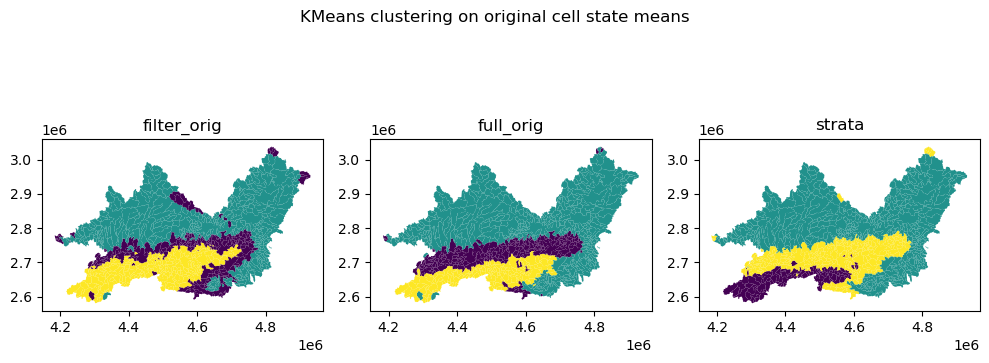

In [17]:
kmeans = KMeans(n_clusters=3, random_state=234, max_iter=100)

label_list = []

fig, axs = plt.subplots(1,3, figsize=(10,10))

for ax, array, name in zip(axs[:2], [filter_r_cs_array, full_r_cs_array], ["filter_orig", "full_orig"]):

	cluster = kmeans.fit_predict(array)
	cell_state_centers = kmeans.cluster_centers_

	label_list.append(cluster)

	lamah_gdf[name] = cluster

	lamah_gdf.plot(column=name, ax=ax)
	ax.set_title(name)

# compute distance to nearest cluster center for each mean cell state 
basin_ids = list(lamah_gdf.index)

for i, cell_state in enumerate(full_r_cs_array):
	
	smallest_dist = np.inf

	for center in cell_state_centers: 

		center_dist = euclidean(cell_state, center)

		if center_dist < smallest_dist: 
			smallest_dist = center_dist
	
	# match numeric id from array to basin id in pd.index
	basin_id = basin_ids[i]

	lamah_gdf.loc[basin_id, "dist_2_nearest_center"] = smallest_dist

# very slight negative correlation between NSE and distance to nearest cluster center. Meaning basins with lower NSE are slighty farther than form cluster centers in stat
print(np.corrcoef(lamah_gdf.NSE, lamah_gdf.dist_2_nearest_center))


lamah_gdf.plot(column="strata", ax=axs[2])
axs[2].set_title("strata")

fig.suptitle("KMeans clustering on original cell state means", y=0.7)
fig.savefig("/home/wuhlmann/BA/repo/lamah-ce_lstm/results/original_cell_state_means_cluster.png", dpi=300)
plt.tight_layout()

<Axes: xlabel='dist_2_nearest_center', ylabel='NSE'>

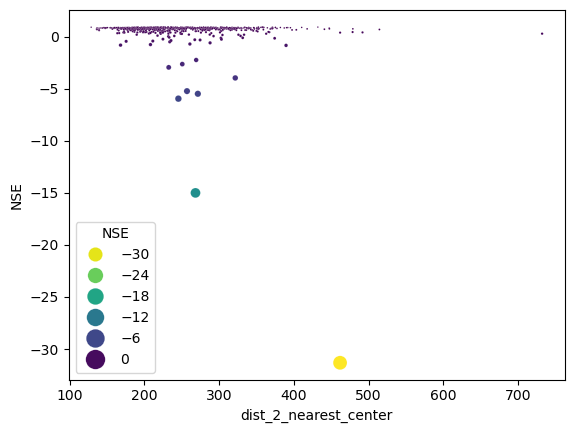

In [18]:
sns.scatterplot(data=lamah_gdf, y="NSE", x="dist_2_nearest_center", size="NSE", hue="NSE", sizes=(100,1), palette="viridis_r")

In [19]:
from sklearn.metrics import jaccard_score

def ugly_label_mapper(x:int): 
	
	relabels ={
		"0": 2,
		"1": 1,
		"2": 0
	}

	return relabels[str(x)]
	

print(f"jaccard mds: {jaccard_score(lamah_gdf['strata'], lamah_gdf['cluster_full_non-metric_r'].apply(ugly_label_mapper), average='weighted')} | jaccard orig: {jaccard_score(lamah_gdf['strata'], lamah_gdf['full_orig'], average='weighted')}")

jaccard mds: 0.8232817683968187 | jaccard orig: 0.5612129287649272


PCA and then k-means clustering, since clusters of stratas appear to be convex. hierch single linkage

we created a regional clustering at the beginning, which the model reproduced in some form. therefore the model represents some regional pattern, which was not explicitly fed into it, but learned from the same + more (dyn) basins characteristics 

### PCA of average cell states of all basins.

Maybe do the PCA on all cell states of the day of predicion, since they hold more information than the average. 

In [ ]:
with open("/home/wuhlmann/BA/data/processed_data/cell_states/512_batch_size_2711_095750_cell_states.p", "rb") as f: 
	filtered_raw_cell_states = pickle.load(f)
	
filtered_raw_cell_states = dict(sorted(filtered_raw_cell_states.items(), key=lambda item: int(item[0])))

with open("/home/wuhlmann/BA/data/processed_data/cell_states/full_q_512_3011_185525_cell_states.p", "rb") as f: 
	full_raw_cell_states = pickle.load(f)

# Since the cell state extraction is done in parallel, the results dict is unorded. Sort by basin id. 
full_raw_cell_states = dict(sorted(full_raw_cell_states.items(), key=lambda item: int(item[0])))


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x14ecc21a61a0>>
Traceback (most recent call last):
  File "/home/wuhlmann/miniforge3/envs/lamah-ce_lstm/lib/python3.10/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


In [ ]:
from sklearn.decomposition import PCA 
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

filter_num_PC_per_basin = {}
full_num_PC_per_basin = {}

filter_traj_len_per_basin = {}
full_traj_len_per_basin = {}

pca_09 = PCA(n_components=0.9, random_state=1277)

for id in tqdm(full_raw_cell_states.keys()):

	for array, PC_dict, traj_dict in zip([filter_raw_cell_states[id]["c_last"], full_raw_cell_states[id]["c_last"]], [filter_num_PC_per_basin, full_num_PC_per_basin], [filter_traj_len_per_basin, full_traj_len_per_basin]): 

		scaled_array = scaler.fit_transform(array)

		pca_09.fit(scaled_array)

		PC_dict[id] = int(len(pca_09.explained_variance_))

		# need to compare the traj len, while considering vastly different ts lenghts

		diff_cs = np.diff(scaled_array, axis=0)

		step_lengths = np.linalg.norm(diff_cs, axis=1)

		traj_dict[id] = step_lengths.sum()


In [ ]:
#load in discharge coverage, to inspect, if there exists correlation between num of PCs and ts length
with open("/home/wuhlmann/BA/data/processed_data/eda/normal_periods.pkl", "rb") as f: 
	discharge_coverage = pickle.load(f)

lamah_gdf["coverage_len"] = discharge_coverage["timeseries_length"]

In [ ]:
len(list(full_num_PC_per_basin.values()))

In [ ]:
fig, axs = plt.subplots(2,2, figsize=(20,10))

for ax, metric_dict, col in zip(axs.ravel(), [filter_num_PC_per_basin, full_num_PC_per_basin, filter_traj_len_per_basin, full_traj_len_per_basin], ["filter_PC", "full_PC", "filter_traj_len", "fullt_traj_len"]):
	
	value_list = list(metric_dict.values())


	lamah_gdf[col] = value_list
	lamah_gdf.plot(column=col, ax=ax)
	ax.set_title(col)
	ax.text(x=4.3e6, y=2.5e6, s=f"Min PC {np.min(value_list)} | Max PC {np.max(value_list)} | Mean PC {np.mean(value_list):.2f}")


plt.tight_layout()

fig.savefig("/home/wuhlmann/BA/repo/lamah-ce_lstm/results/num_PC_per_basin.png", dpi=300)

In [ ]:
import seaborn as sns

fig, axs = plt.subplots(1,2, figsize=(20,10))

sns.regplot(x=lamah_gdf["full_PC"], y=lamah_gdf["coverage_len"], ax=axs[0])
sns.regplot(x=lamah_gdf["filter_PC"], y=lamah_gdf["coverage_len"], ax=axs[1])